# Training models taking account the Data Reducing

## Loading the Database

### Using Augmentations

In [1]:
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import numpy as np

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_CLASSES = 1
IMAGES_TO_USE = 1
CROP = "sorghum"  # "wheat" or "sorghum"

dataset_path = f"../data/{CROP}/"

class SegmentationDataset(Dataset):
    def __init__(self, root_dir, train=True, num_augs_to_use=1, seed=None):
        self.root_dir = root_dir
        self.train = train
        self.img_dir = os.path.join(root_dir, "train/images" if train else "test/images")
        self.mask_dir = os.path.join(root_dir, "train/masks" if train else "test/masks")
        self.num_augs_to_use = num_augs_to_use
        self.rng = random.Random(seed)

        # Find base filenames (without augmentation suffix)
        base_files = set()
        for f in os.listdir(self.img_dir):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                base = f.split('_aug')[0] if '_aug' in f else os.path.splitext(f)[0]
                base_files.add(base)

        # For each base file, collect available augmentations
        self.samples = []
        for base in sorted(base_files):
            aug_indices = []
            for aug in range(1, 6):
                img_name = f"{base}_aug{aug}.jpg"
                mask_name = f"{base}_aug{aug}.png"
                if os.path.exists(os.path.join(self.img_dir, img_name)) and os.path.exists(os.path.join(self.mask_dir, mask_name)):
                    aug_indices.append(aug)
            # If original (no _aug) exists, add as aug=0
            img_name = f"{base}.png"
            mask_name = f"{base}.png"
            if os.path.exists(os.path.join(self.img_dir, img_name)) and os.path.exists(os.path.join(self.mask_dir, mask_name)):
                aug_indices.append(0)
            # Randomly select num_augs_to_use augmentations for this base
            if len(aug_indices) > 0:
                selected_augs = self.rng.sample(aug_indices, min(num_augs_to_use, len(aug_indices)))
                for aug in selected_augs:
                    self.samples.append((base, aug))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        base, aug = self.samples[idx]
        if aug == 0:
            img_name = f"{base}.jpg"
            mask_name = f"{base}.png"
        else:
            img_name = f"{base}_aug{aug}.jpg"
            mask_name = f"{base}_aug{aug}.png"

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        mask = torch.from_numpy(np.array(mask)).float().unsqueeze(0)
        mask = (mask > 0).float()

        return image, mask

# Example usage:
train_dataset = SegmentationDataset(dataset_path, train=True, num_augs_to_use=IMAGES_TO_USE, seed=666)
test_dataset = SegmentationDataset(dataset_path, train=False, num_augs_to_use=IMAGES_TO_USE, seed=666)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"✅ Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

✅ Train size: 2677 | Test size: 1148


### Removing Images

In [1]:
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import numpy as np
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_CLASSES = 1
CROP = "sorghum"  # "wheat" or "sorghum"
REMOVE_PCT = 0.5  # Remove 10% of images
SEED = 666

dataset_path = f"../data/{CROP}/"

class SegmentationDataset(Dataset):
    def __init__(self, root_dir, train=True, remove_pct=0.0, seed=None):
        self.root_dir = root_dir
        self.train = train
        self.img_dir = os.path.join(root_dir, "train/images" if train else "test/images")
        self.mask_dir = os.path.join(root_dir, "train/masks" if train else "test/masks")
        self.rng = random.Random(seed)

        # Get all image/mask files but exclude any augmented files containing '_aug'
        image_files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg')) and '_aug' not in f.lower()
        ])
        mask_files = sorted([
            f for f in os.listdir(self.mask_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg')) and '_aug' not in f.lower()
        ])

        # Build maps by basename (without extension) to keep pairing robust across extensions
        image_map = {os.path.splitext(f)[0]: f for f in image_files}
        mask_map = {os.path.splitext(f)[0]: f for f in mask_files}

        # Keep only basenames present in both image and mask dirs
        common_basenames = sorted(set(image_map.keys()) & set(mask_map.keys()))

        # Randomly remove a percentage of images (based on basenames)
        n_total = len(common_basenames)
        n_keep = int(n_total * (1 - remove_pct))
        # ensure at least zero
        n_keep = max(0, n_keep)

        self.rng.shuffle(common_basenames)
        keep_basenames = common_basenames[:n_keep]

        # Create aligned lists
        self.image_files = [image_map[b] for b in keep_basenames]
        self.mask_files = [mask_map[b] for b in keep_basenames]

        assert len(self.image_files) == len(self.mask_files), \
            f"Image/Mask count mismatch: {len(self.image_files)} vs {len(self.mask_files)}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        mask = torch.from_numpy(np.array(mask)).float().unsqueeze(0)
        mask = (mask > 0).float()

        return image, mask

train_dataset = SegmentationDataset(dataset_path, train=True, remove_pct=REMOVE_PCT, seed=SEED)
test_dataset = SegmentationDataset(dataset_path, train=False, remove_pct=REMOVE_PCT, seed=SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"✅ Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

✅ Train size: 1338 | Test size: 574


In [2]:
for i in range(3):
    img, mask = train_dataset[i]
    print(img.shape, mask.shape)

torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])


## Importing Models

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


### U-NET for wheat

In [3]:
import sys
sys.path.append('../')
from utils.models.uNet import UNet

channels = [32, 64, 128, 256, 512]
model = UNet(in_channels=3, out_channels=1, channels=channels, bilinear=True, use_batchnorm=True)
model.to(device)
modelName = "U-NET"

### SegFormer for sorghum

In [3]:
import sys
sys.path.append('../')
from utils.models.SegFormer import segformer

model = segformer(in_channels = 3, num_classes = 1)
model.to(device)
modelName = "SegFormer"

c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Training

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [5]:
# --- Configuration ---
EPOCHS = 200
early_stopping_patience = 5
best_val_loss = float('inf') 
patience_counter = 0
scaler = torch.amp.GradScaler('cuda')

# --- Loss & Optimizer ---
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

#checkpoint_path = os.path.join("../models/", CROP + "_" + modelName + "_" + str(IMAGES_TO_USE) + "_seg.pt")
checkpoint_path = os.path.join("../models/", CROP + "_" + modelName + "_" + str(round(REMOVE_PCT*100)) + "less" + "_seg.pt")
print(f"Model checkpoints will be saved to: {checkpoint_path}")

# --- Tracking ---
train_losses, val_losses = [], []

Model checkpoints will be saved to: ../models/sorghum_SegFormer_50less_seg.pt


In [6]:
# --- Training Loop ---
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as tepoch:
        for inputs, labels in tepoch:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                    print("NaN or Inf in model outputs!")
                if torch.isnan(labels).any() or torch.isinf(labels).any():
                    print("NaN or Inf in labels!")
                if labels.sum() == 0:
                    print("Skipping batch with all empty masks")
                    continue
                loss = loss_fn(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            tepoch.set_postfix(loss=running_loss / (len(tepoch)))
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        with tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation", unit="batch") as vepoch:
            for inputs, labels in vepoch:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                        print("NaN or Inf in model outputs!")
                    if torch.isnan(labels).any() or torch.isinf(labels).any():
                        print("NaN or Inf in labels!")
                    if labels.sum() == 0:
                        print("Skipping batch with all empty masks")
                        continue
                    loss = loss_fn(outputs, labels)
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()
                val_acc = val_correct / val_total if val_total > 0 else 0
                val_loss += loss.item()
                vepoch.set_postfix(loss=val_loss / (len(vepoch)))

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}%")

    # --- Scheduler step (use validation loss) ---
    lr_scheduler.step(avg_val_loss)

    # --- Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✅ Model improved (Val Loss={avg_val_loss:.3f}), saved to {checkpoint_path}")
    else:
        patience_counter += 1
        print(f"🔴 No improvement, patience counter: {patience_counter}")

    if patience_counter >= early_stopping_patience:
        print("🛑 Early stopping triggered!")
        break

Epoch 1/200 - Validation: 100%|██████████| 72/72 [00:10<00:00,  6.86batch/s, loss=0.111] 


Epoch 1 - Val Loss: 0.1109 - Val Acc: 0.9571%
✅ Model improved (Val Loss=0.111), saved to ../models/sorghum_SegFormer_50less_seg.pt


Epoch 2/200 - Validation: 100%|██████████| 72/72 [00:08<00:00,  8.31batch/s, loss=0.0991] 


Epoch 2 - Val Loss: 0.0991 - Val Acc: 0.9596%
✅ Model improved (Val Loss=0.099), saved to ../models/sorghum_SegFormer_50less_seg.pt


Epoch 3/200 - Validation: 100%|██████████| 72/72 [00:07<00:00,  9.04batch/s, loss=0.0759] 


...

Epoch 25 - Val Loss: 0.0457 - Val Acc: 0.9834%
🔴 No improvement, patience counter: 3


Epoch 26/200 - Validation: 100%|██████████| 72/72 [00:08<00:00,  8.53batch/s, loss=0.0459] 


Epoch 26 - Val Loss: 0.0459 - Val Acc: 0.9836%
🔴 No improvement, patience counter: 4


Epoch 27/200 - Validation: 100%|██████████| 72/72 [00:08<00:00,  8.71batch/s, loss=0.046]  

Epoch 27 - Val Loss: 0.0460 - Val Acc: 0.9834%
🔴 No improvement, patience counter: 5
🛑 Early stopping triggered!


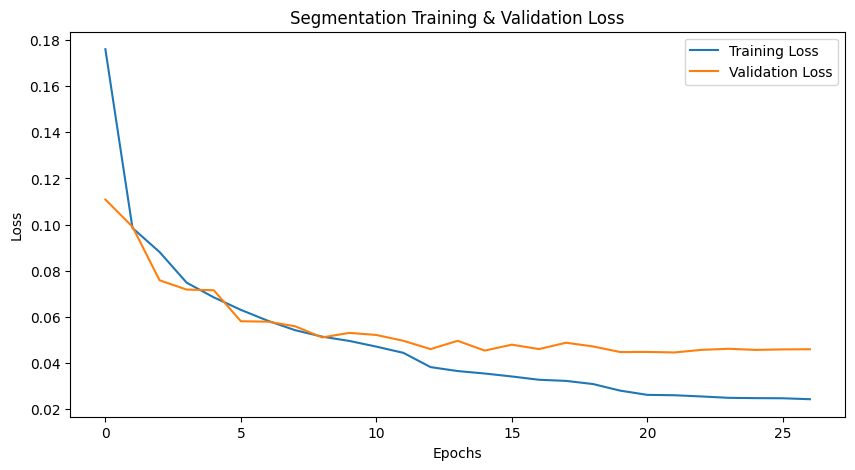

In [7]:
# --- Plot losses ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Segmentation Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference on Test Image

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_23216\2977633742.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


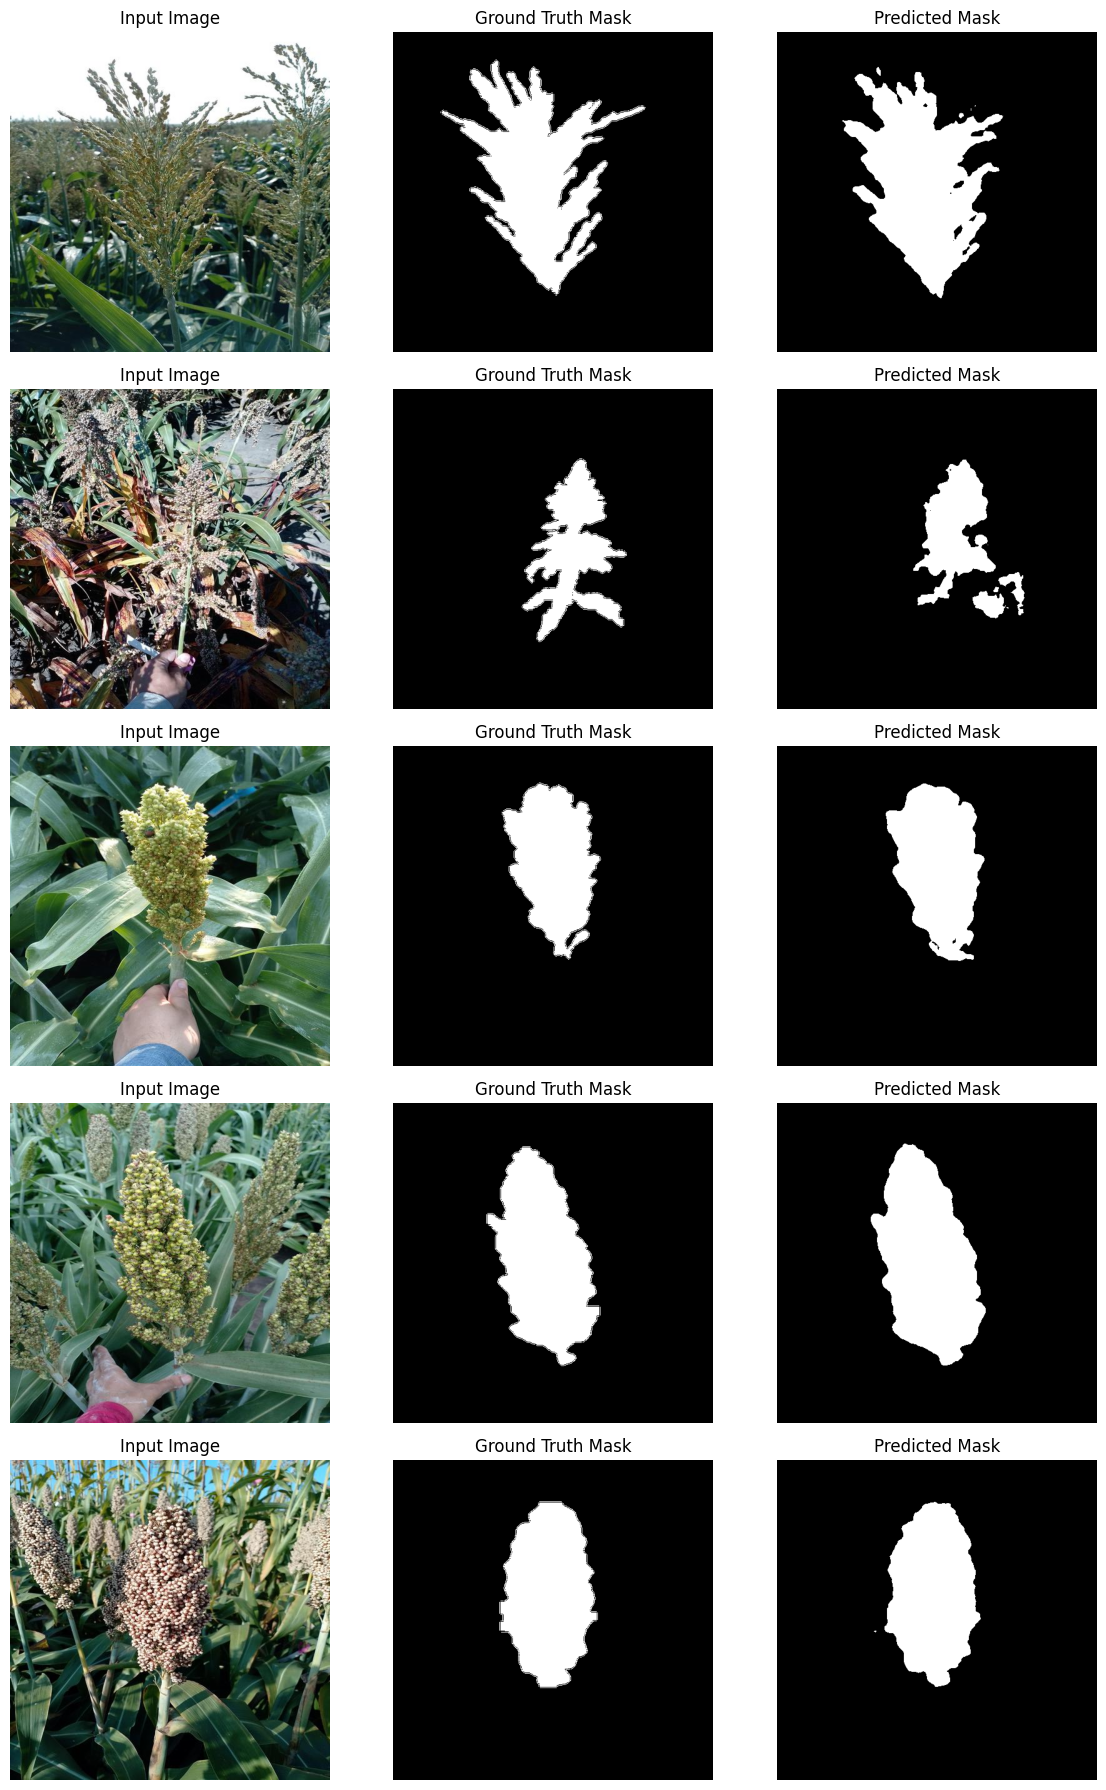

In [8]:
import random

# Pick 5 random indices from the test dataset
indices = random.sample(range(len(test_dataset)), 5)

fig, axs = plt.subplots(5, 3, figsize=(12, 18))
for i, idx in enumerate(indices):
    img, mask = test_dataset[idx]
    img_input = img.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            pred_logits = model(img_input)
            pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()
    axs[i, 0].imshow(img.permute(1, 2, 0).cpu() * 0.5 + 0.5)
    axs[i, 0].set_title("Input Image")
    axs[i, 1].imshow(mask.squeeze().cpu(), cmap='gray')
    axs[i, 1].set_title("Ground Truth Mask")
    axs[i, 2].imshow(pred_mask, cmap='gray')
    axs[i, 2].set_title("Predicted Mask")
    for j in range(3):
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()


In [10]:
import time
from PIL import Image
import torchvision.transforms.functional as TF

# --- Config ---
IMG_PATH = "../data/{}/test/images/1_1_5.jpg".format(CROP)  # <-- set your image path

model.eval()

# --- Preprocess image ---
img = Image.open(IMG_PATH).convert("RGB")
img = img.resize((512, 512))  # resize if needed
img_tensor = TF.to_tensor(img)
img_tensor = TF.normalize(img_tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
img_tensor = img_tensor.unsqueeze(0).to(device)

# --- Inference with timing ---
with torch.no_grad():
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    with torch.cuda.amp.autocast():
        pred_logits = model(img_tensor)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    end = time.time()
    pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()

print(f"Inference time: {end - start:.4f} seconds")

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_3968\2723461262.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Inference time: 0.3363 seconds
